<a href="https://colab.research.google.com/github/Akritz2004/demand-forecasting/blob/main/DemandForcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv('DemandForecastingDataset.csv')

In [ ]:
df.rename(columns={'??????????': 'Products'}, inplace=True)
df.rename(columns={'Actual_Sales_Qty': 'Actual_Sales_Qty_Y'}, inplace=True)

In [ ]:
rc = {'C22ES210044' : 'MAINTENACE PARTS KIT',
      'C22ES090013-50': 'Head Cleaning Set' ,
      'C22ES090013-SET5': 'MAGENTA IC (700ML)',
      'C22ES210115': 'BLACK IC (700ML)',
      'INK-T6641': 'LIGHT CYAN IC (700ML)',
      'PAPER-A4-80G': 'RED IC (700ML)'
      }

In [ ]:
df["Products"] = df["Products"].replace(rc)
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()


In [ ]:
df["Products"].unique()

array(['Head Cleaning Set', 'MAGENTA IC (700ML)', 'MAINTENACE PARTS KIT',
       'BLACK IC (700ML)', 'LIGHT CYAN IC (700ML)', 'RED IC (700ML)'],
      dtype=object)

In [ ]:
df.head()

,Products,Date,Year,Month,Quarter,Seasonality_Index,Promotion_Flag,Economic_Trend,Lead_Time_Days,Beginning_Stock,Incoming_PO,Sales_Lag1,Sales_Lag2,Sales_Lag3,Rolling_Mean_3M,Actual_Sales_Qty_Y
0,Head Cleaning Set,2023-04-01,2023,4,2,0.55,0,1.0,45,93,0,166,143,173,160.666667,84
1,Head Cleaning Set,2023-05-01,2023,5,2,0.51,0,1.0,30,49,11,84,166,143,131.000000,77
2,Head Cleaning Set,2023-06-01,2023,6,2,1.01,0,1.0,30,171,29,77,84,166,109.000000,153
3,Head Cleaning Set,2023-07-01,2023,7,3,1.19,0,1.0,7,200,15,153,77,84,104.666667,181
4,Head Cleaning Set,2023-08-01,2023,8,3,0.92,1,1.0,45,192,34,181,153,77,137.000000,181


In [ ]:
print(df[df['Products'] == 'Head Cleaning Set'])

             Products       Date  Year  Month  Quarter  Seasonality_Index  \
0   Head Cleaning Set 2023-04-01  2023      4        2               0.55   
1   Head Cleaning Set 2023-05-01  2023      5        2               0.51   
2   Head Cleaning Set 2023-06-01  2023      6        2               1.01   
3   Head Cleaning Set 2023-07-01  2023      7        3               1.19   
4   Head Cleaning Set 2023-08-01  2023      8        3               0.92   
5   Head Cleaning Set 2023-09-01  2023      9        3               0.90   
6   Head Cleaning Set 2023-10-01  2023     10        4               1.05   
7   Head Cleaning Set 2023-11-01  2023     11        4               1.88   
8   Head Cleaning Set 2023-12-01  2023     12        4               1.98   
9   Head Cleaning Set 2024-01-01  2024      1        1               1.12   
10  Head Cleaning Set 2024-02-01  2024      2        1               1.00   
11  Head Cleaning Set 2024-03-01  2024      3        1               1.19   

เลือกสินค้ามา 1 ชิ้นก่อน คือ Head Cleaning Set


In [ ]:
df['Products'].unique()


array(['Head Cleaning Set', 'MAGENTA IC (700ML)', 'MAINTENACE PARTS KIT',
       'BLACK IC (700ML)', 'LIGHT CYAN IC (700ML)', 'RED IC (700ML)'],
      dtype=object)

In [ ]:
df_single = df[df['Products'] == 'Head Cleaning Set'].copy()

# แบ่ง Train (2023-2024) และ Test (2025)
train = df_single[df_single['Year'] <= 2024].copy()
test = df_single[df_single['Year'] == 2025].copy()

SARIMA

In [ ]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
train_ts = train.set_index('Date')['Actual_Sales_Qty_Y']
test_ts = test.set_index('Date')['Actual_Sales_Qty_Y']

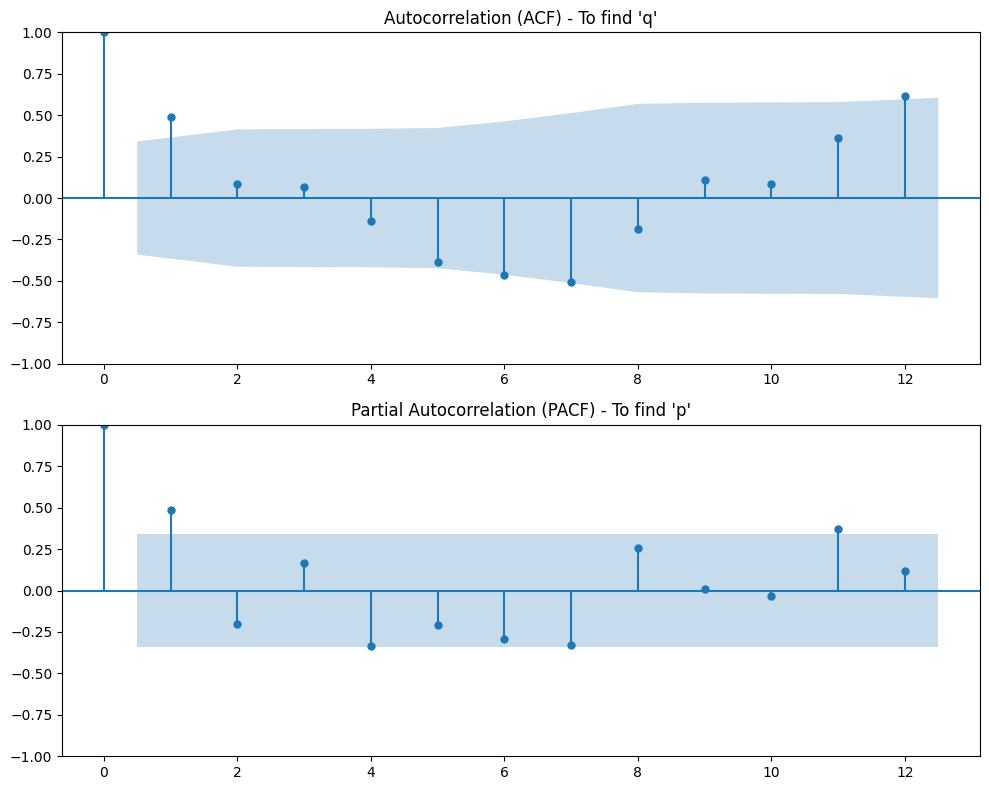

In [ ]:
df_monthly_s = df_single.set_index('Date').resample('ME')['Actual_Sales_Qty_Y'].sum()

# 2. ตรวจสอบว่ามีค่าว่างไหม (ถ้ามีให้เติม 0)
df_monthly_s = df_monthly_s.fillna(0)

# 3. Plot ACF และ PACF เพื่อหาค่า p, q
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# ACF: ช่วยหาค่า q (MA term)
plot_acf(df_monthly_s, lags=12, ax=ax1)
ax1.set_title("Autocorrelation (ACF) - To find 'q'")

# PACF: ช่วยหาค่า p (AR term)
plot_pacf(df_monthly_s, lags=12, ax=ax2)
ax2.set_title("Partial Autocorrelation (PACF) - To find 'p'")

plt.tight_layout()
plt.show()

In [ ]:
sarima_model = sm.tsa.statespace.SARIMAX(train_ts,
                                         order=(1, 1, 1),
                                         seasonal_order=(1, 1, 1, 12),
                                         enforce_stationarity=False,
                                         enforce_invertibility=False)

sarima_result = sarima_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



In [ ]:
sarima_pred = sarima_result.predict(start=test_ts.index[0], end=test_ts.index[-1])

print("SARIMA MAE:", mean_absolute_error(test_ts, sarima_pred))

SARIMA MAE: 29.515197039421015


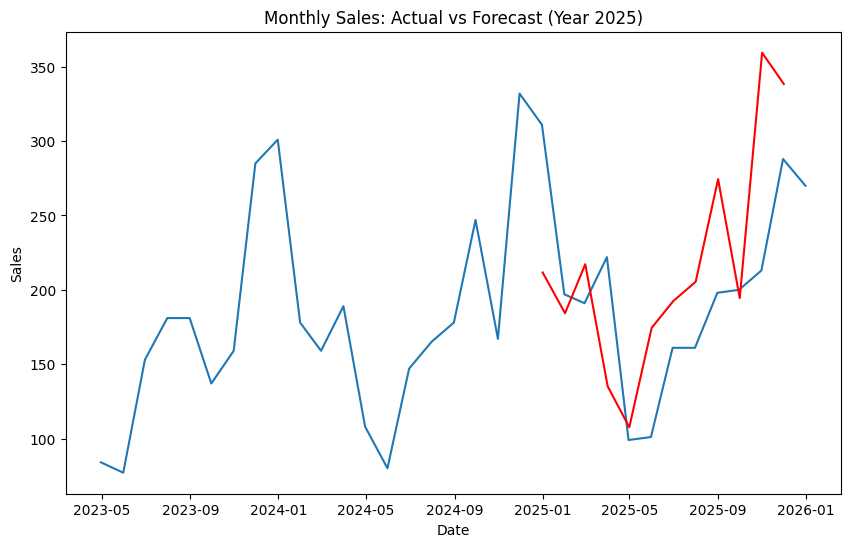

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_monthly_s, label='Observed')
plt.plot(sarima_pred, label='Forecast', color='red')
plt.title("Monthly Sales: Actual vs Forecast (Year 2025)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

Prophet
 เครื่องมือ Open-source สำหรับพยากรณ์ข้อมูลอนุกรมเวลา (Time Series Forecasting) พัฒนาโดย Facebook (Meta) ในปี 2017 โดยเน้นความง่ายในการใช้งาน ความแม่นยำสูง และความรวดเร็ว เหมาะสำหรับข้อมูลธุรกิจที่มีลักษณะฤดูกาล (Seasonality) ชัดเจน

In [ ]:
from prophet import Prophet

In [ ]:
#ต้องเปลี่ยนชื่อ Column เป็น ds y ก่อน
df_prophet_train = train[['Date', 'Actual_Sales_Qty_Y', 'Promotion_Flag']].rename(columns={'Date': 'ds', 'Actual_Sales_Qty_Y': 'y'})
df_prophet_test = test[['Date', 'Actual_Sales_Qty_Y', 'Promotion_Flag']].rename(columns={'Date': 'ds', 'Actual_Sales_Qty_Y': 'y'})

In [ ]:
m = Prophet(seasonality_mode='multiplicative') # ใช้ multiplicative เพราะยอดขายมักสวิงตามฤดูกาล
m.add_regressor('Promotion_Flag') # บอกให้ AI รู้ว่ามีตัวแปรโปรโมชั่นด้วย

In [ ]:
m.fit(df_prophet_train)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 15.


In [ ]:
# สร้างตารางอนาคต และพยากรณ์
future = m.make_future_dataframe(periods=len(df_prophet_test), freq='MS')
future['Promotion_Flag'] = df_single['Promotion_Flag'].values # ใส่ค่าโปรโมชั่นของจริงเข้าไป
prophet_forecast = m.predict(future)

In [ ]:
prophet_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Promotion_Flag,Promotion_Flag_lower,Promotion_Flag_upper,extra_regressors_multiplicative,extra_regressors_multiplicative_lower,extra_regressors_multiplicative_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2023-04-01,126.327444,45.392330,213.004468,126.327444,126.327444,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,126.327444
1,2023-05-01,131.239569,50.533192,210.095028,131.239569,131.239569,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,131.239569
2,2023-06-01,136.315431,56.627507,217.364755,136.315431,136.315431,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,136.315431
3,2023-07-01,141.227556,63.381004,230.056001,141.227556,141.227556,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,0.0,141.227556
4,2023-08-01,146.303418,85.819079,244.293944,146.303418,146.303418,0.15051,0.15051,0.15051,0.15051,0.15051,0.15051,0.15051,0.15051,0.15051,0.0,0.0,0.0,168.323554


In [ ]:
prophet_pred = prophet_forecast.iloc[-len(test):]['yhat']

print("Prophet MAE:", mean_absolute_error(df_prophet_test['y'], prophet_pred))

Prophet MAE: 74.43580118795545


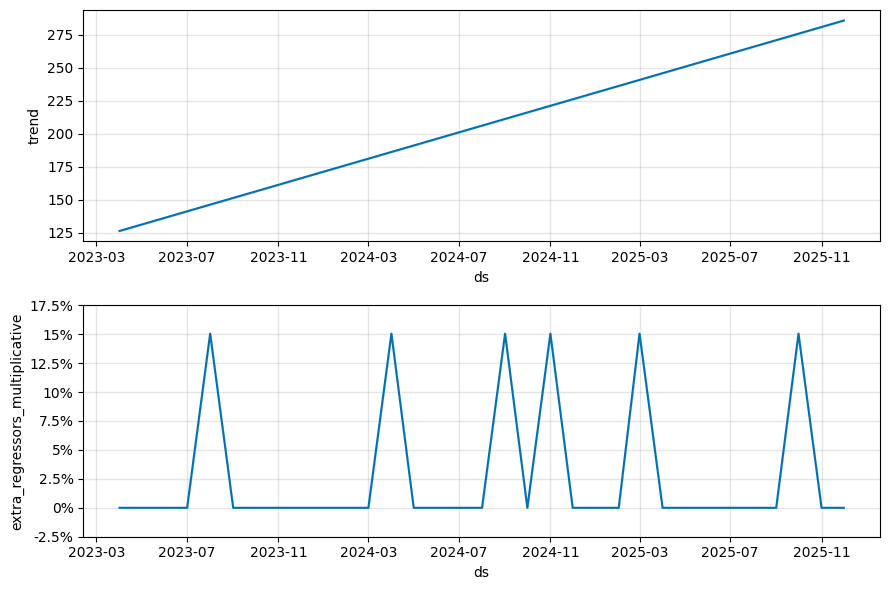

In [ ]:
flg = m.plot_components(prophet_forecast)

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly
plot_plotly(m, prophet_forecast)

XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
train = df[df['Year'] <= 2024].copy()
test = df[df['Year'] == 2025].copy()

In [ ]:
features = ['Month', 'Quarter', 'Seasonality_Index', 'Promotion_Flag',
            'Economic_Trend', 'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3', 'Rolling_Mean_3M']
target = 'Actual_Sales_Qty_Y'

In [ ]:
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))

XGBoost MAE: 65.01286315917969


In [ ]:
results_df = test.copy()
results_df['Predicted_Y_พยากรณ์'] = xgb_pred.round(0).astype(int)

In [ ]:
importance = pd.DataFrame({'Feature': features, 'Importance': xgb_model.feature_importances_})
print("\nความสำคัญของตัวแปร:\n", importance.sort_values(by='Importance', ascending=False))


ความสำคัญของตัวแปร:
              Feature  Importance
8    Rolling_Mean_3M    0.441288
2  Seasonality_Index    0.345622
7         Sales_Lag3    0.078154
0              Month    0.053632
5         Sales_Lag1    0.044771
3     Promotion_Flag    0.016553
6         Sales_Lag2    0.014854
4     Economic_Trend    0.005125
1            Quarter    0.000000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

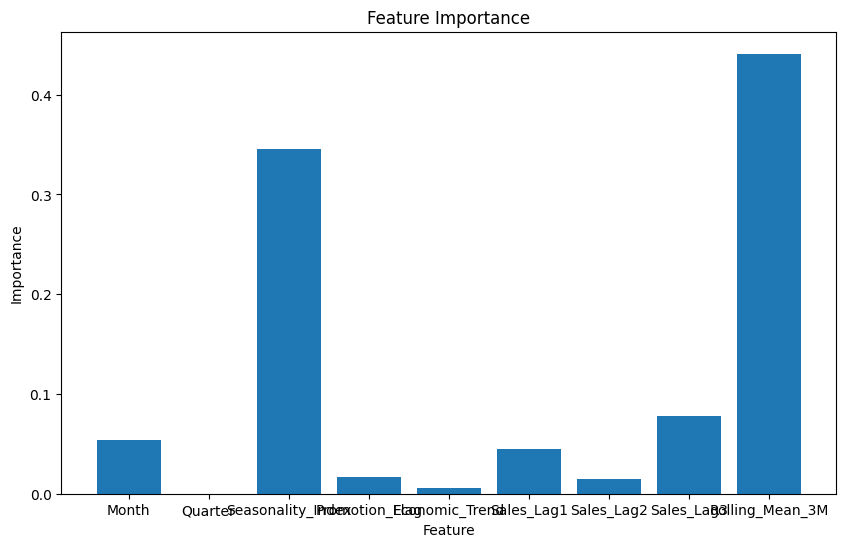

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(importance['Feature'], importance['Importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt

In [ ]:
results_df = X_test.copy() # เอาตารางโจทย์ตั้งต้นมา
results_df['Actual_Y_จริง'] = y_test # แปะเฉลยลงไป
results_df['Predicted_Y_พยากรณ์'] = xgb_pred # แปะผลที่โมเดลทายลงไป

# ปัดทศนิยมให้เป็นจำนวนเต็ม (เพราะยอดขายต้องเป็นชิ้น)
results_df['Predicted_Y_พยากรณ์'] = results_df['Predicted_Y_พยากรณ์'].round(0).astype(int)

# สร้างคอลัมน์ดูว่าทายผิดไปกี่ชิ้น
results_df['Error_คลาดเคลื่อน'] = results_df['Predicted_Y_พยากรณ์'] - results_df['Actual_Y_จริง']

# เลือกคอลัมน์มาดูให้เข้าใจง่าย
columns_to_show = ['Sales_Lag1', 'Month', 'Seasonality_Index', 'Actual_Y_จริง', 'Predicted_Y_พยากรณ์', 'Error_คลาดเคลื่อน']
print(results_df[columns_to_show])

     Sales_Lag1  Month  Seasonality_Index  Actual_Y_จริง  Predicted_Y_พยากรณ์  \
21          311      1               1.18            197                  405   
22          197      2               1.14            191                  413   
23          191      3               1.02            222                  265   
24          222      4               0.60             99                  155   
25           99      5               0.61            101                  104   
..          ...    ...                ...            ...                  ...   
193         445      8               1.17            467                  555   
194         467      9               1.01            520                  409   
195         520     10               0.97            387                  448   
196         387     11               1.86            740                  665   
197         740     12               1.97            783                  767   

     Error_คลาดเคลื่อน  
21

In [ ]:
export_cols = [
    'Products', 'Date', 'Year', 'Month', 'Quarter', 'Seasonality_Index', 'Promotion_Flag',
    'Actual_Sales_Qty_Y', 'Predicted_Y_พยากรณ์',
    'Beginning_Stock', 'Incoming_PO', 'Lead_Time_Days'
]

# Create a temporary DataFrame for export, starting with the original test data
# and adding the predicted values.
temp_export_df = test.copy()
temp_export_df['Predicted_Y_พยากรณ์'] = results_df['Predicted_Y_พยากรณ์']

final_export_df = temp_export_df[export_cols].copy()

#เปลี่ยนชื่อคอลัมน์ให้ Power BI อ่านง่ายๆ
final_export_df.rename(columns={
    'Actual_Sales_Qty_Y': 'ยอดขายจริง',
    'Predicted_Y_พยากรณ์': 'ยอดพยากรณ์_AI',
    'Beginning_Stock': 'สต็อกปัจจุบัน',
    'Incoming_PO': 'ของที่กำลังมา_PO',
    'Lead_Time_Days': 'Lead_Time_วัน'
}, inplace=True)

#Export ไฟล์ออกมาเลย
final_export_df.to_excel('PowerBI_Forecast_Dashboard_All_Products.xlsx', index=False)


Export ข้อมูลครบทุก Product เรียบร้อยแล้วครับ!


In [ ]:
#export_cols = [
    #'Products', 'Date', 'Year', 'Month', 'Quarter', 'Seasonality_Index', 'Promotion_Flag',
    #'Actual_Sales_Qty_Y', 'Predicted_Y_พยากรณ์',
    #'Beginning_Stock', 'Incoming_PO', 'Lead_Time_Days'
#]

#final_export_df = results_df[export_cols].copy()

#เปลี่ยนชื่อคอลัมน์ให้ Power BI อ่านง่ายๆ
#final_export_df.rename(columns={
    ##'Predicted_Y_พยากรณ์': 'ยอดพยากรณ์_AI',
    #'Beginning_Stock': 'สต็อกปัจจุบัน',
   #'Incoming_PO': 'ของที่กำลังมา_PO',
    #'Lead_Time_Days': 'Lead_Time_วัน'
#}, inplace=True)

#Export ไฟล์ออกมาเลย
##final_export_df.to_excel('PowerBI_Forecast_Dashboard_All_Products.xlsx', index=False)
